# Individualized Frequency Estimation from Resting-State EEG
## StarStim .easy File Analysis Pipeline

**Purpose:** Estimate participant-specific oscillatory peak frequencies (theta, alpha, beta) from resting-state EEG recorded with a 7-electrode StarStim montage, using spectral parameterization (specparam/FOOOF) and classical peak-detection approaches.

**Montage:** 1=F3, 2=Fp1, 3=FCz, 4=FT7, 5=F4, 6=P4, 7=P3

**Empirical precedents & rationale:**

This notebook implements two complementary strategies for individualized frequency estimation that are well-supported in the tACS literature:

1. **Classical peak detection (Welch PSD + Savitzky-Golay smoothing):** The approach from [Corcoran et al. (2018)](https://doi.org/10.1111/psyp.13064) for reliable, automated individual alpha frequency (IAF) estimation, adapted here for frontal midline theta. Multiple tACS studies use this approach: resting-state eyes-closed EEG at Fz within 4–8 Hz (e.g., the FM-theta neurofeedback mega-analysis by Enriquez-Geppert et al., 2014; the midfrontal theta tACS study by Fusco et al., 2021).

2. **Spectral parameterization (specparam/FOOOF):** Decomposes the power spectrum into aperiodic (1/f) and periodic (oscillatory) components ([Donoghue et al., 2020](https://doi.org/10.1038/s41593-020-00744-x)). This is important because a raw PSD peak can be confounded by individual differences in the aperiodic slope — what looks like a theta peak could just be a steeper 1/f falloff. Specparam separates the two, yielding a cleaner estimate of whether a genuine oscillatory peak exists and at what frequency.

**Key design choice — resting-state vs. task-locked:**
Several studies derive individualized theta from task-related EEG (e.g., during N-back or Stroop). However, for our tACS bandit protocol, resting-state estimation is more practical: the theta frequency is needed *before* the task runs. The FM-theta mega-analysis found that resting-state-derived peaks from eyes-closed Fz are adequate and widely used. The Reinhart & Nguyen (2019) memory-theta tACS study similarly used resting EEG for individualized frequency selection.

---


## Step 0: Imports & Configuration

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.ndimage import gaussian_filter1d
from pathlib import Path
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Optional: specparam (formerly FOOOF) for spectral parameterization
try:
    from specparam import SpectralModel, SpectralGroupModel
    SPECPARAM_AVAILABLE = True
    print(f"specparam available (v{__import__('specparam').__version__})")
except ImportError:
    SPECPARAM_AVAILABLE = False
    print("specparam not installed — install with: pip install specparam")
    print("Classical peak detection will still work.")

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'font.size': 11,
    'lines.linewidth': 1.5,
})


specparam available (v2.0.0rc6)


In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — edit these for your recording
# ══════════════════════════════════════════════════════════════════════════════

EASY_FILE = Path("~/Documents/GitHub/tacs_bandit/data/nic/raw/20260602150340_sub-rebecca-pilot-2_Run 1.easy").expanduser()

# Channel mapping: StarStim electrode number → 10-20 label
# Adjust if your .info file shows a different ordering
CHANNEL_MAP = {
    0: 'F3',
    1: 'Fp1',
    2: 'FCz',
    3: 'FT7',
    4: 'F4',
    5: 'P4',
    6: 'P3',
}
N_EEG_CHANNELS = 7

# StarStim nominal sampling rate
SRATE = 500  # Hz

# Units: StarStim .easy files store EEG in nanovolts (nV)
# We convert to microvolts (µV) for standard processing
NV_TO_UV = 1e-3

# Frequency bands of interest
BANDS = {
    'theta':  (4.0, 8.0),
    'alpha':  (8.0, 13.0),
    'beta':   (13.0, 30.0),
}

# Primary target: theta
PRIMARY_BAND = 'theta'

# ROI channels for frontal midline theta
THETA_ROI = ['FCz', 'F3', 'F4']

# ROI channels for posterior alpha (as secondary measure)
ALPHA_ROI = ['P3', 'P4']

# Preprocessing
HIGHPASS_HZ = 0.5
LOWPASS_HZ = 45.0
NOTCH_HZ = 60.0  # US line noise

# Welch PSD parameters
WELCH_NPERSEG = 2 * SRATE   # 2-second windows → 0.5 Hz resolution
WELCH_NOVERLAP = SRATE      # 50% overlap


## Step 1: Load the .easy File

The `.easy` format is Neuroelectrics' native ASCII format. Each row is a sample. Columns are:
- Columns 0–(N-1): EEG channels in **nanovolts**
- Column N: Flags / markers
- Last column: Unix timestamp in **milliseconds**

The Starstim records at 500 Hz (2 ms between samples). The timestamp column uses the NecBox clock anchored to the PC's system time at recording start.


In [39]:
def load_easy_file(filepath, n_eeg_channels=7, srate=500):
    """
    Load a Neuroelectrics .easy file.
    
    Returns
    -------
    eeg : ndarray, shape (n_samples, n_eeg_channels), in nanovolts
    markers : ndarray, shape (n_samples,)
    timestamps_ms : ndarray, shape (n_samples,), Unix time in ms
    """
    filepath = Path(filepath)
    if not filepath.exists():
        raise FileNotFoundError(f"File not found: {filepath}")
    
    print(f"Loading: {filepath.name}")
    data = np.loadtxt(filepath)
    print(f"  Raw shape: {data.shape}")
    
    n_cols = data.shape[1]
    # Expected: n_eeg_channels + flags_column + timestamp_column
    # But sometimes there are additional columns (e.g., accelerometer, stim channels)
    # The last column is always the timestamp
    # We'll take the first n_eeg_channels as EEG
    
    eeg = data[:, :n_eeg_channels]
    markers = data[:, n_eeg_channels]  # flag/marker column right after EEG
    timestamps_ms = data[:, -1]        # last column is always timestamp
    
    # Compute actual sampling rate from timestamps
    dt_ms = np.diff(timestamps_ms)
    actual_srate = 1000.0 / np.median(dt_ms[dt_ms > 0])
    
    duration_sec = (timestamps_ms[-1] - timestamps_ms[0]) / 1000.0
    
    print(f"  EEG channels: {n_eeg_channels}")
    print(f"  Total columns: {n_cols}")
    print(f"  Samples: {len(eeg):,}")
    print(f"  Duration: {duration_sec:.1f} s ({duration_sec/60:.1f} min)")
    print(f"  Nominal srate: {srate} Hz")
    print(f"  Actual median srate: {actual_srate:.1f} Hz")
    print(f"  Unique markers: {np.unique(markers[markers != 0])}")
    
    return eeg, markers, timestamps_ms

# Load the data
eeg_nv, markers, timestamps_ms = load_easy_file(EASY_FILE, N_EEG_CHANNELS, SRATE)

# Convert nV → µV
eeg_uv = eeg_nv * NV_TO_UV

# Create channel names
ch_names = [CHANNEL_MAP[i] for i in range(N_EEG_CHANNELS)]
print(f"\nChannel labels: {ch_names}")


Loading: 20260602150340_sub-rebecca-pilot-2_Run 1.easy
  Raw shape: (180000, 13)
  EEG channels: 7
  Total columns: 13
  Samples: 180,000
  Duration: 360.0 s (6.0 min)
  Nominal srate: 500 Hz
  Actual median srate: 500.0 Hz
  Unique markers: [-4.00000047e+08]

Channel labels: ['F3', 'Fp1', 'FCz', 'FT7', 'F4', 'P4', 'P3']


## Step 2: Raw Data Inspection

Before any processing, we need to visually inspect the raw traces and check for obvious artifacts (flatlines, saturation, excessive drift, disconnected channels).


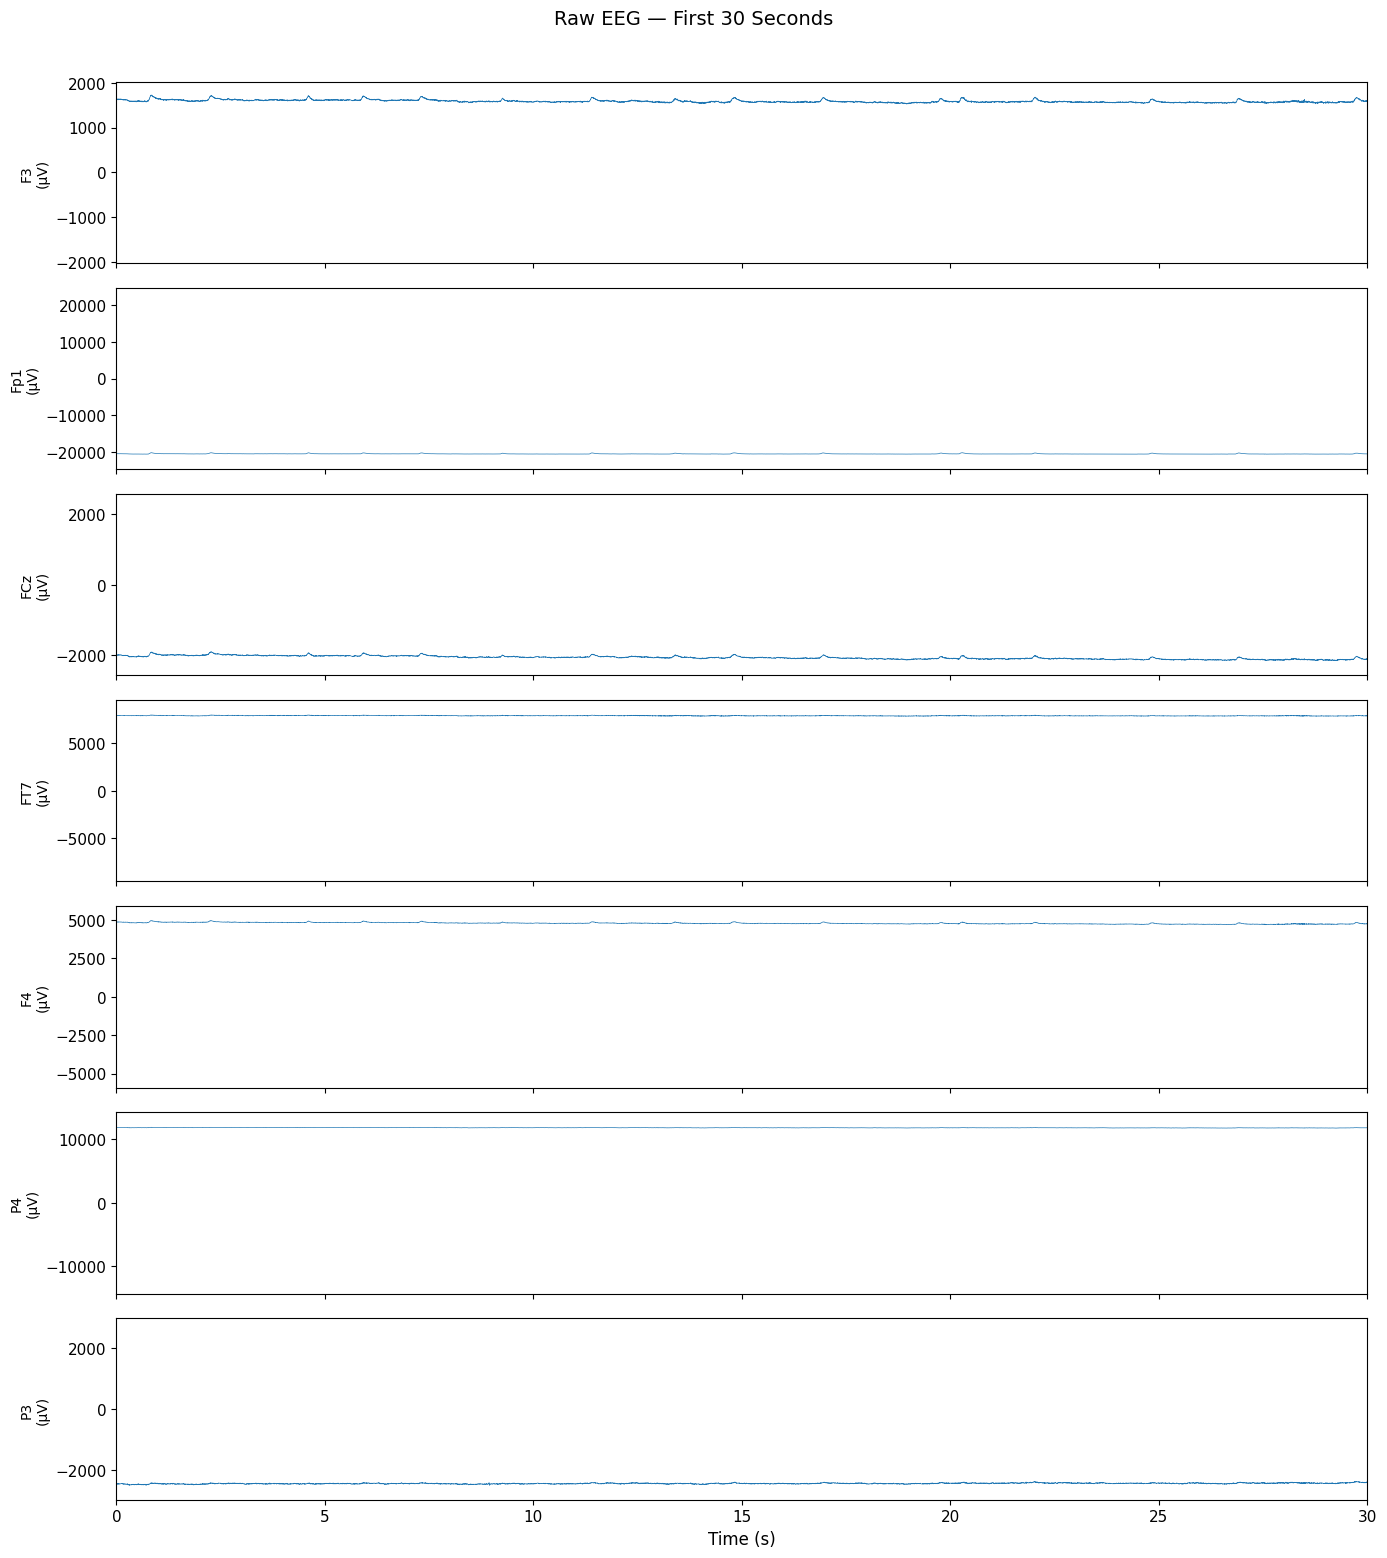

In [42]:
# Time vector in seconds (relative to start)
time_sec = (timestamps_ms - timestamps_ms[0]) / 1000.0

# Plot raw traces (first 30 seconds)
fig, axes = plt.subplots(N_EEG_CHANNELS, 1, figsize=(14, 2.2 * N_EEG_CHANNELS), sharex=True)
t_end = min(30, time_sec[-1])  # first 30s or whole recording if shorter
mask = time_sec <= t_end

for i, (ax, name) in enumerate(zip(axes, ch_names)):
    ax.plot(time_sec[mask], eeg_uv[mask, i], linewidth=0.5, color='C0')
    ax.set_ylabel(f'{name}\n(µV)', fontsize=10)
    ax.set_xlim(0, t_end)
    # Mark ±200 µV range for reference
    yrange = np.percentile(np.abs(eeg_uv[mask, i]), 99)
    ax.set_ylim(-yrange * 1.2, yrange * 1.2)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Raw EEG — First 30 Seconds', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()


In [43]:
# Channel quality summary
print("Channel Quality Summary")
print("=" * 65)
print(f"{'Channel':<10} {'Mean(µV)':<12} {'SD(µV)':<12} {'Max|µV|':<12} {'Flatline(s)':<12}")
print("-" * 65)

for i, name in enumerate(ch_names):
    ch = eeg_uv[:, i]
    sd = np.std(ch)
    mn = np.mean(ch)
    mx = np.max(np.abs(ch))
    
    # Flatline detection: consecutive identical values
    diffs = np.abs(np.diff(ch))
    flat_mask = diffs < 1e-6
    longest_flat = 0
    current = 0
    for is_flat in flat_mask:
        if is_flat:
            current += 1
            longest_flat = max(longest_flat, current)
        else:
            current = 0
    flat_sec = longest_flat / SRATE
    
    flag = ""
    if sd < 0.1: flag += " ⚠️ LOW_VAR"
    if sd > 200: flag += " ⚠️ HIGH_VAR"
    if flat_sec > 2: flag += " ⚠️ FLATLINE"
    
    print(f"{name:<10} {mn:<12.2f} {sd:<12.2f} {mx:<12.1f} {flat_sec:<12.2f}{flag}")


Channel Quality Summary
Channel    Mean(µV)     SD(µV)       Max|µV|      Flatline(s) 
-----------------------------------------------------------------
F3         1338.36      246.20       1852.8       0.00         ⚠️ HIGH_VAR
Fp1        -20645.95    181.55       21194.0      0.00        
FCz        -2959.44     660.74       4362.7       0.00         ⚠️ HIGH_VAR
FT7        7594.84      315.78       8073.9       0.00         ⚠️ HIGH_VAR
F4         4154.53      488.13       5012.7       0.01         ⚠️ HIGH_VAR
P4         11367.61     352.37       11912.8      0.00         ⚠️ HIGH_VAR
P3         -2044.01     214.12       2530.7       0.00         ⚠️ HIGH_VAR


## Step 3: Preprocessing

Minimal preprocessing for spectral estimation:
1. **Bandpass filter** (0.5–45 Hz, 4th-order Butterworth, zero-phase)
2. **Notch filter** at 60 Hz (US line noise)
3. **Average re-reference** across good channels

We intentionally keep this simple — no ICA, no epoch rejection — because we're estimating resting-state spectra from continuous data, and specparam is robust to residual artifacts when averaging over long segments.


In [45]:
def preprocess_eeg(eeg, srate, highpass=0.5, lowpass=45.0, notch=60.0, bad_channels=None):
    """
    Minimal preprocessing: bandpass, notch, average re-reference.
    
    Parameters
    ----------
    eeg : ndarray (n_samples, n_channels), in µV
    srate : float
    highpass, lowpass : filter edges in Hz
    notch : line noise frequency (0 to skip)
    bad_channels : list of int, channel indices to exclude from re-reference
    
    Returns
    -------
    eeg_clean : ndarray, same shape
    """
    eeg_clean = eeg.copy()
    nyq = srate / 2.0
    
    # 1. Bandpass
    b, a = signal.butter(4, [highpass / nyq, lowpass / nyq], btype='band')
    eeg_clean = signal.filtfilt(b, a, eeg_clean, axis=0)
    
    # 2. Notch filter (60 Hz)
    if notch > 0 and notch < nyq:
        b_notch, a_notch = signal.iirnotch(notch / nyq, Q=30.0)
        eeg_clean = signal.filtfilt(b_notch, a_notch, eeg_clean, axis=0)
    
    # 3. Average re-reference (excluding bad channels)
    if bad_channels is None:
        bad_channels = []
    good_idx = [i for i in range(eeg_clean.shape[1]) if i not in bad_channels]
    ref = np.mean(eeg_clean[:, good_idx], axis=1, keepdims=True)
    eeg_clean -= ref
    
    return eeg_clean

# Identify any bad channels from the quality summary above
# (manually specify indices here if any looked problematic)
BAD_CHANNEL_IDX = []  # e.g., [1] to exclude Fp1

eeg_clean = preprocess_eeg(
    eeg_uv, SRATE,
    highpass=HIGHPASS_HZ, lowpass=LOWPASS_HZ, notch=NOTCH_HZ,
    bad_channels=BAD_CHANNEL_IDX,
)

print(f"Preprocessed EEG shape: {eeg_clean.shape}")
print(f"Bad channels excluded from re-reference: {[ch_names[i] for i in BAD_CHANNEL_IDX] or 'none'}")


Preprocessed EEG shape: (180000, 7)
Bad channels excluded from re-reference: none


## Step 4: Power Spectral Density (Welch's Method)

Compute the PSD for each channel using Welch's method with 2-second Hanning windows and 50% overlap. This gives 0.5 Hz frequency resolution — sufficient for resolving peaks within the theta band (4–8 Hz).


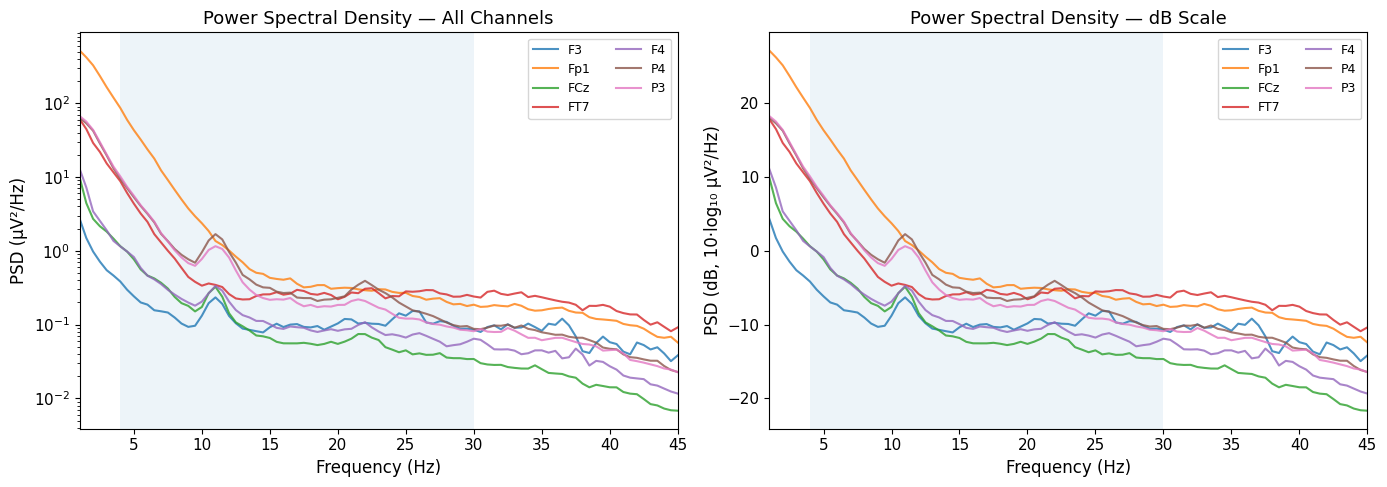

In [50]:
# Compute Welch PSD for all channels
freqs, psd_all = signal.welch(
    eeg_clean, fs=SRATE, nperseg=WELCH_NPERSEG, noverlap=WELCH_NOVERLAP,
    axis=0, window='hann',
)

# Convert to dB (10 * log10)
psd_db = 10 * np.log10(np.maximum(psd_all, 1e-30))

# Trim to 1–45 Hz for plotting
freq_mask = (freqs >= 1) & (freqs <= 45)

# ── Plot 1: All channels, linear scale ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i, name in enumerate(ch_names):
    if i in BAD_CHANNEL_IDX:
        continue
    ax1.semilogy(freqs[freq_mask], psd_all[freq_mask, i], label=name, alpha=0.8)
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('PSD (µV²/Hz)')
ax1.set_title('Power Spectral Density — All Channels')
ax1.legend(ncol=2, fontsize=9)
ax1.set_xlim(1, 45)

# Shade bands
for band_name, (lo, hi) in BANDS.items():
    ax1.axvspan(lo, hi, alpha=0.08, label=band_name)

# ── Plot 2: dB scale ──
for i, name in enumerate(ch_names):
    if i in BAD_CHANNEL_IDX:
        continue
    ax2.plot(freqs[freq_mask], psd_db[freq_mask, i], label=name, alpha=0.8)
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('PSD (dB, 10·log₁₀ µV²/Hz)')
ax2.set_title('Power Spectral Density — dB Scale')
ax2.legend(ncol=2, fontsize=9)
ax2.set_xlim(1, 45)

for band_name, (lo, hi) in BANDS.items():
    ax2.axvspan(lo, hi, alpha=0.08)

fig.tight_layout()
plt.show()


## Step 5: ROI-Averaged Spectra

For **frontal midline theta**, we average across FCz, F3, F4. This is the standard approach for FM-theta — the spectral peak at FCz (and surrounding frontal sites) in the 4–8 Hz range.

For **posterior alpha**, we average across P3, P4. Alpha peaks are typically strongest at posterior sites during eyes-closed rest.


Theta ROI:
  ROI channels used: ['F3', 'FCz', 'F4']
Alpha ROI:
  ROI channels used: ['P4', 'P3']


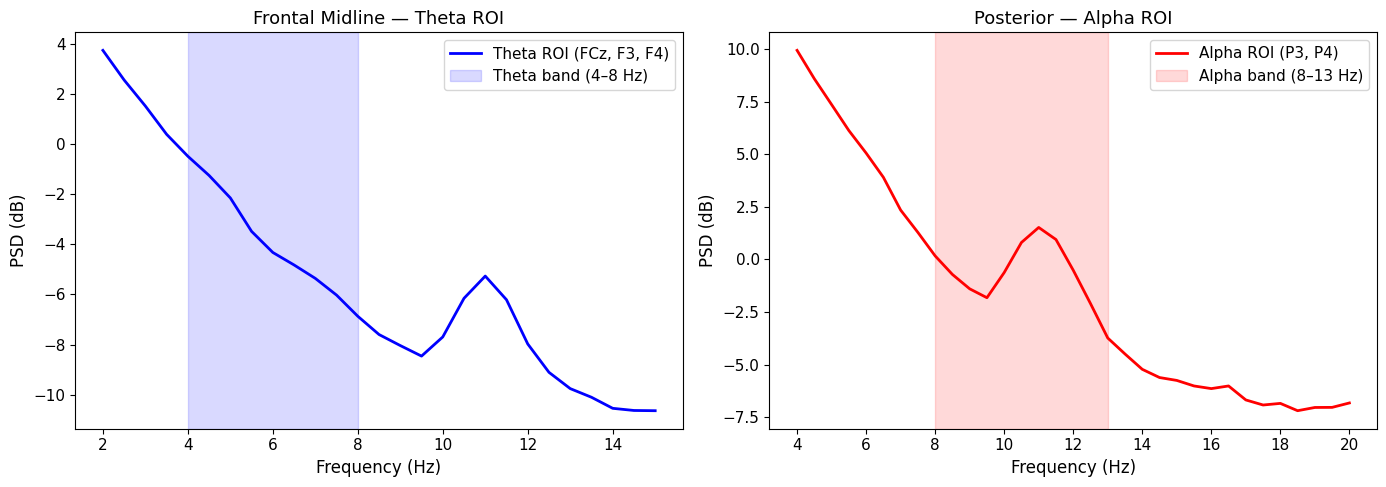

In [52]:
def get_roi_spectrum(ch_names, psd, roi_labels, bad_idx=None):
    """Average PSD across ROI channels, skipping bad ones."""
    if bad_idx is None:
        bad_idx = []
    idx = [i for i, name in enumerate(ch_names) if name in roi_labels and i not in bad_idx]
    if not idx:
        print(f"  WARNING: No usable channels for ROI {roi_labels}")
        return np.zeros(psd.shape[0])
    used = [ch_names[i] for i in idx]
    print(f"  ROI channels used: {used}")
    return np.mean(psd[:, idx], axis=1)

# Theta ROI
print("Theta ROI:")
theta_psd = get_roi_spectrum(ch_names, psd_all, THETA_ROI, BAD_CHANNEL_IDX)

# Alpha ROI
print("Alpha ROI:")
alpha_psd = get_roi_spectrum(ch_names, psd_all, ALPHA_ROI, BAD_CHANNEL_IDX)

# Plot ROI spectra
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Theta ROI
theta_mask = (freqs >= 2) & (freqs <= 15)
ax1.plot(freqs[theta_mask], 10*np.log10(np.maximum(theta_psd[theta_mask], 1e-30)), 
         'b-', linewidth=2, label='Theta ROI (FCz, F3, F4)')
ax1.axvspan(*BANDS['theta'], alpha=0.15, color='blue', label='Theta band (4–8 Hz)')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('PSD (dB)')
ax1.set_title('Frontal Midline — Theta ROI')
ax1.legend()

# Alpha ROI
alpha_mask = (freqs >= 4) & (freqs <= 20)
ax2.plot(freqs[alpha_mask], 10*np.log10(np.maximum(alpha_psd[alpha_mask], 1e-30)), 
         'r-', linewidth=2, label='Alpha ROI (P3, P4)')
ax2.axvspan(*BANDS['alpha'], alpha=0.15, color='red', label='Alpha band (8–13 Hz)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('PSD (dB)')
ax2.set_title('Posterior — Alpha ROI')
ax2.legend()

fig.tight_layout()
plt.show()


## Step 6: Classical Peak Detection (Savitzky-Golay Smoothing)

This implements the approach from Corcoran et al. (2018): smooth the PSD with a Savitzky-Golay filter, then find the peak within the band of interest. We also compute prominence to assess whether a genuine spectral peak exists vs. just 1/f falloff.

For each band, we report:
- **Peak frequency (Hz)**
- **Peak prominence (z-score)** — how much the peak stands out above the local baseline
- **Edge peak flag** — whether the peak is at the band boundary (unreliable)


In [56]:
def find_spectral_peak(freqs, psd, band, smooth_hz=0.5, min_prominence_z=0.5):
    """
    Find the dominant spectral peak within a frequency band.
    
    Uses Savitzky-Golay smoothing and scipy peak detection.
    
    Parameters
    ----------
    freqs : 1D array of frequencies
    psd : 1D array of power values (linear scale)
    band : (low_hz, high_hz)
    smooth_hz : Gaussian smoothing width
    min_prominence_z : minimum z-scored prominence to accept a peak
    
    Returns
    -------
    dict with peak_hz, prominence_z, edge_peak, passes_criteria, smoothed_spectrum
    """
    lo, hi = band
    band_mask = (freqs >= lo) & (freqs <= hi)
    band_freqs = freqs[band_mask]
    band_psd = psd[band_mask]
    
    if len(band_freqs) == 0:
        return {'peak_hz': None, 'prominence_z': 0, 'edge_peak': True, 
                'passes_criteria': False, 'smoothed_psd': None}
    
    # Convert to dB for smoothing and peak detection
    band_psd_db = 10 * np.log10(np.maximum(band_psd, 1e-30))
    
    # Gaussian smoothing
    freq_step = np.mean(np.diff(band_freqs))
    if smooth_hz > 0 and freq_step > 0:
        sigma_bins = smooth_hz / freq_step / 2.355
        smoothed = gaussian_filter1d(band_psd_db, sigma=max(sigma_bins, 0.5), mode='nearest')
    else:
        smoothed = band_psd_db
    
    # Find peaks with prominence
    peak_idx, properties = signal.find_peaks(smoothed, prominence=0)
    
    if len(peak_idx) > 0:
        # Select the highest peak
        heights = smoothed[peak_idx]
        best = np.argmax(heights)
        pk_idx = peak_idx[best]
        prominence = properties['prominences'][best]
    else:
        # No local maximum — take argmax (but it's probably an edge)
        pk_idx = np.argmax(smoothed)
        prominence = 0.0
    
    peak_hz = float(band_freqs[pk_idx])
    edge = pk_idx in {0, len(band_freqs) - 1}
    prom_z = prominence / max(np.std(smoothed), 1e-12)
    passes = (prom_z >= min_prominence_z) and not edge
    
    return {
        'peak_hz': peak_hz,
        'prominence_z': float(prom_z),
        'edge_peak': bool(edge),
        'passes_criteria': bool(passes),
        'smoothed_psd': smoothed,
        'band_freqs': band_freqs,
    }

# ── Run peak detection for each band × ROI ──
results = {}

print("Classical Peak Detection Results")
print("=" * 70)
print(f"{'Band':<8} {'ROI':<20} {'Peak (Hz)':<12} {'Prom (z)':<12} {'Edge?':<8} {'Pass?'}")
print("-" * 70)

for band_name, band_range in BANDS.items():
    if band_name in ('theta',):
        roi_psd = theta_psd
        roi_label = 'Frontal (FCz,F3,F4)'
    elif band_name in ('alpha',):
        roi_psd = alpha_psd
        roi_label = 'Posterior (P3,P4)'
    else:
        # Beta: use frontal ROI
        roi_psd = theta_psd
        roi_label = 'Frontal (FCz,F3,F4)'
    
    result = find_spectral_peak(freqs, roi_psd, band_range)
    results[band_name] = result
    
    pk = result['peak_hz']
    pz = result['prominence_z']
    edge = '✗' if not result['edge_peak'] else '⚠️ YES'
    pas = '✓' if result['passes_criteria'] else '✗'
    print(f"{band_name:<8} {roi_label:<20} {pk:<12.2f} {pz:<12.2f} {edge:<8} {pas}")


Classical Peak Detection Results
Band     ROI                  Peak (Hz)    Prom (z)     Edge?    Pass?
----------------------------------------------------------------------
theta    Frontal (FCz,F3,F4)  4.00         0.00         ⚠️ YES   ✗
alpha    Posterior (P3,P4)    11.00        2.20         ✗        ✓
beta     Frontal (FCz,F3,F4)  22.00        1.69         ✗        ✓


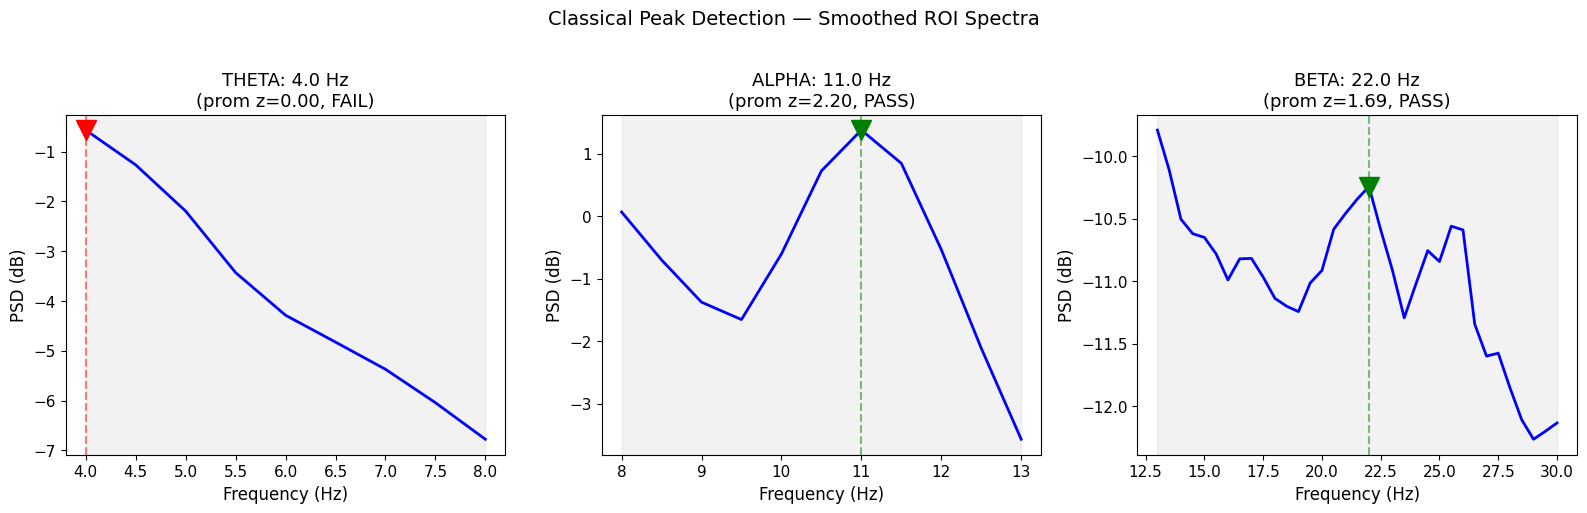

In [58]:
# Visualize peak detection for theta and alpha
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (band_name, band_range) in zip(axes, BANDS.items()):
    result = results[band_name]
    if result['smoothed_psd'] is not None:
        ax.plot(result['band_freqs'], result['smoothed_psd'], 'b-', linewidth=2)
        
        # Mark peak
        if result['peak_hz'] is not None:
            peak_idx = np.argmin(np.abs(result['band_freqs'] - result['peak_hz']))
            marker_color = 'green' if result['passes_criteria'] else 'red'
            ax.plot(result['peak_hz'], result['smoothed_psd'][peak_idx], 
                    'v', color=marker_color, markersize=14, zorder=5)
            ax.axvline(result['peak_hz'], color=marker_color, linestyle='--', alpha=0.5)
            ax.set_title(f"{band_name.upper()}: {result['peak_hz']:.1f} Hz\n"
                        f"(prom z={result['prominence_z']:.2f}, "
                        f"{'PASS' if result['passes_criteria'] else 'FAIL'})")
    
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD (dB)')
    ax.axvspan(*band_range, alpha=0.1, color='gray')

fig.suptitle('Classical Peak Detection — Smoothed ROI Spectra', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


## Step 7: Spectral Parameterization (specparam / FOOOF)

This is the critical step that separates genuine oscillatory peaks from the aperiodic (1/f) background. The specparam algorithm:

1. Fits the aperiodic component (1/f slope + offset) in log-log space
2. Subtracts the aperiodic fit to create a "flattened" spectrum
3. Fits Gaussian peaks to any remaining bumps in the flattened spectrum
4. Reports center frequency, bandwidth, and power for each detected peak

**Why this matters for your tACS study:** If you set stimulation frequency based on a raw PSD peak that's actually just a 1/f artifact (no genuine oscillation), the stimulation won't be targeting a real neural rhythm. Specparam tells you whether a real periodic component exists.

**Settings used:**
- Frequency range: 2–40 Hz (wide enough for aperiodic fit)
- Peak width limits: 1–6 Hz (appropriate for theta/alpha)
- Max number of peaks: 4
- Aperiodic mode: 'fixed' (no knee; appropriate for 2–40 Hz range)


In [61]:
if SPECPARAM_AVAILABLE:
    
    # ── Fit specparam to each ROI ──
    specparam_results = {}
    
    for roi_name, (roi_psd, roi_labels) in {
        'theta_roi': (theta_psd, THETA_ROI),
        'alpha_roi': (alpha_psd, ALPHA_ROI),
    }.items():
        
        # specparam works on linear power, not dB
        sm = SpectralModel(
            peak_width_limits=[1.0, 6.0],
            max_n_peaks=4,
            min_peak_height=0.1,  # in log10 power units
            aperiodic_mode='fixed',
        )
        
        # Fit on 2–40 Hz range
        sm.fit(freqs, roi_psd, freq_range=[2, 40])
        specparam_results[roi_name] = sm
        
        # ── Extract results (specparam 2.0 API) ──
        ap_params = sm.results.params.aperiodic.params   # [offset, exponent]
        pk_params = sm.results.params.periodic.params     # (n_peaks, 3): [cf, pw, bw]
        r_squared = sm.results.metrics.results['gof_rsquared']
        error_mae = sm.results.metrics.results['error_mae']
        
        print(f"\n{'='*50}")
        print(f"ROI: {roi_name} ({roi_labels})")
        print(f"{'='*50}")
        print(f"Aperiodic: offset={ap_params[0]:.3f}, "
              f"exponent={ap_params[1]:.3f}")
        print(f"R² (model fit): {r_squared:.4f}")
        print(f"Error (MAE): {error_mae:.4f}")
        
        if pk_params.size > 0 and pk_params.ndim == 2:
            print(f"\nDetected peaks:")
            print(f"  {'Center (Hz)':<15} {'Power':<12} {'Bandwidth (Hz)'}")
            for peak in pk_params:
                cf, pw, bw = peak
                # Identify which band this falls in
                band_label = ""
                for bn, (lo, hi) in BANDS.items():
                    if lo <= cf <= hi:
                        band_label = f"  ← {bn}"
                        break
                print(f"  {cf:<15.2f} {pw:<12.3f} {bw:.2f}{band_label}")
        else:
            print("  No peaks detected above threshold.")
    
else:
    print("specparam not available. Skip this cell or install with:")
    print("  pip install specparam")
    specparam_results = {}


ROI: theta_roi (['FCz', 'F3', 'F4'])
Aperiodic: offset=0.691, exponent=1.418
R² (model fit): 0.9718
Error (MAE): 0.0567

Detected peaks:
  Center (Hz)     Power        Bandwidth (Hz)
  11.09           0.320        1.05  ← alpha
  25.01           0.217        6.00  ← beta
  34.44           0.213        6.00

ROI: alpha_roi (['P3', 'P4'])
Aperiodic: offset=1.736, exponent=1.895
R² (model fit): 0.9948
Error (MAE): 0.0429

Detected peaks:
  Center (Hz)     Power        Bandwidth (Hz)
  3.00            0.424        4.45
  11.27           0.394        1.45  ← alpha
  22.66           0.272        3.47  ← beta


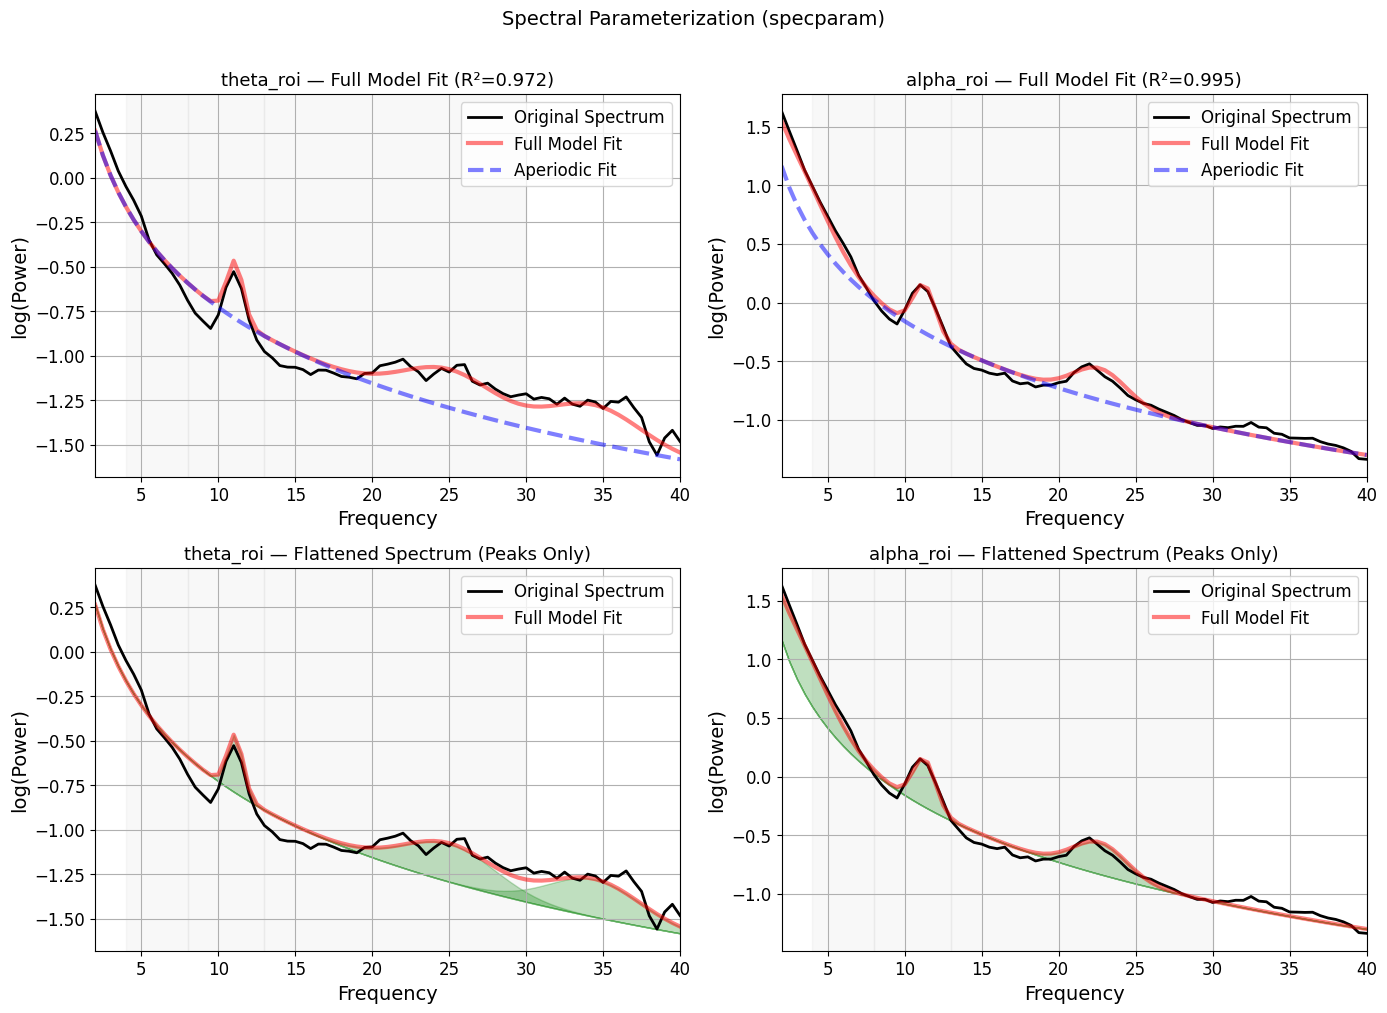

In [63]:
if SPECPARAM_AVAILABLE and specparam_results:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    for col, (roi_name, sm) in enumerate(specparam_results.items()):
        r_squared = sm.results.metrics.results['gof_rsquared']
        
        # Top row: full model fit
        ax = axes[0, col]
        sm.plot(ax=ax, plt_log=False)
        ax.set_title(f'{roi_name} — Full Model Fit (R²={r_squared:.3f})')
        ax.set_xlim(2, 40)
        
        # Bottom row: flattened (aperiodic-subtracted) spectrum
        ax = axes[1, col]
        sm.plot(ax=ax, plt_log=False, plot_peaks='shade', plot_aperiodic=False)
        ax.set_title(f'{roi_name} — Flattened Spectrum (Peaks Only)')
        ax.set_xlim(2, 40)
        
        # Mark band boundaries
        for band_name, (lo, hi) in BANDS.items():
            ax.axvspan(lo, hi, alpha=0.05, color='gray')
            axes[0, col].axvspan(lo, hi, alpha=0.05, color='gray')
    
    fig.suptitle('Spectral Parameterization (specparam)', fontsize=14, y=1.01)
    fig.tight_layout()
    plt.show()
    
else:
    print("Skipped — specparam not available.")

## Step 8: Per-Channel Spectral Parameterization

Run specparam on each individual channel to see the spatial distribution of oscillatory peaks. This helps verify that theta is genuinely frontal-midline and alpha is genuinely posterior.


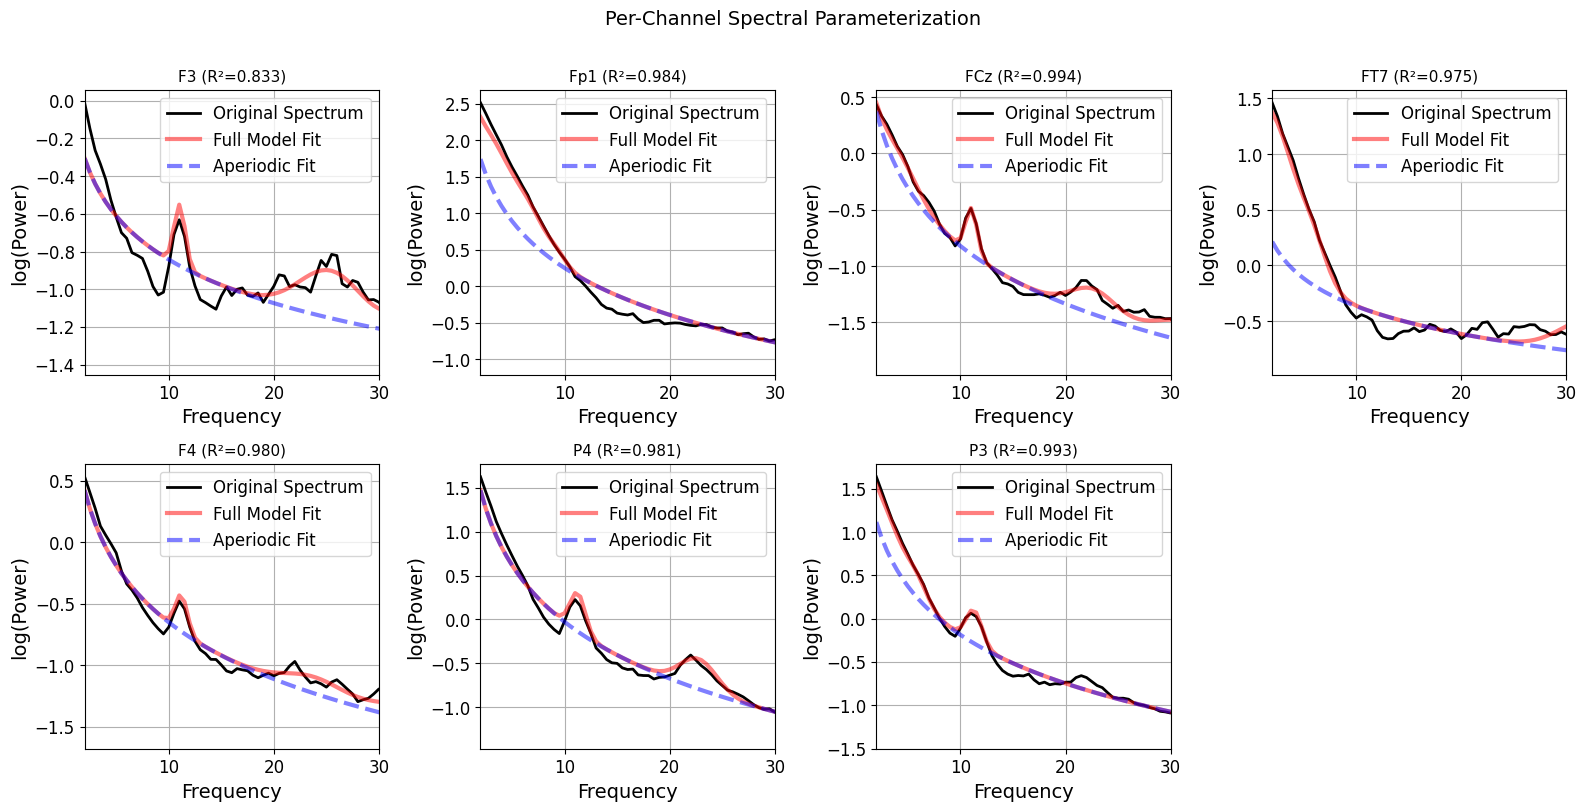


Per-Channel Peak Summary
Channel    theta (Hz)     theta pwr  alpha (Hz)     alpha pwr  beta (Hz)      beta pwr  
---------------------------------------------------------------------------
F3         ---            ---        11.04          0.323      25.42          0.253     
Fp1        6.86           0.487      9.34           0.180      ---            ---       
FCz        4.37           0.190      11.05          0.409      22.64          0.225     
FT7        5.91           0.545      ---            ---        ---            ---       
F4         ---            ---        11.20          0.281      23.82          0.134     
P4         ---            ---        11.25          0.417      22.74          0.342     
P3         5.89           0.273      11.30          0.370      ---            ---       


In [66]:
if SPECPARAM_AVAILABLE:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    per_channel_peaks = {}
    
    for i, name in enumerate(ch_names):
        if i in BAD_CHANNEL_IDX:
            axes[i].set_visible(False)
            continue
        
        ax = axes[i]
        sm = SpectralModel(
            peak_width_limits=[1.0, 6.0],
            max_n_peaks=4,
            min_peak_height=0.1,
            aperiodic_mode='fixed',
        )
        sm.fit(freqs, psd_all[:, i], freq_range=[2, 40])
        r_sq = sm.results.metrics.results['gof_rsquared']
        sm.plot(ax=ax, plt_log=False)
        ax.set_title(f'{name} (R²={r_sq:.3f})', fontsize=11)
        ax.set_xlim(2, 30)
        
        # Store peak info
        peaks_in_bands = {}
        pk_params = sm.results.params.periodic.params
        if pk_params.size > 0 and pk_params.ndim == 2:
            for peak in pk_params:
                cf, pw, bw = peak
                for bn, (lo, hi) in BANDS.items():
                    if lo <= cf <= hi:
                        if bn not in peaks_in_bands or pw > peaks_in_bands[bn]['power']:
                            peaks_in_bands[bn] = {'freq': cf, 'power': pw, 'bw': bw}
        per_channel_peaks[name] = peaks_in_bands
    
    # Hide unused subplot
    if len(ch_names) < len(axes):
        for j in range(len(ch_names), len(axes)):
            axes[j].set_visible(False)
    
    fig.suptitle('Per-Channel Spectral Parameterization', fontsize=14, y=1.01)
    fig.tight_layout()
    plt.show()
    
    # Summary table
    print("\nPer-Channel Peak Summary")
    print("=" * 75)
    print(f"{'Channel':<10}", end='')
    for bn in BANDS:
        print(f" {bn+' (Hz)':<14} {bn+' pwr':<10}", end='')
    print()
    print("-" * 75)
    for name in ch_names:
        if name not in per_channel_peaks:
            continue
        print(f"{name:<10}", end='')
        for bn in BANDS:
            if bn in per_channel_peaks[name]:
                pk = per_channel_peaks[name][bn]
                print(f" {pk['freq']:<14.2f} {pk['power']:<10.3f}", end='')
            else:
                print(f" {'---':<14} {'---':<10}", end='')
        print()

else:
    print("Skipped — specparam not available.")

## Step 9: Summary & Frequency Selection

This cell consolidates all estimates and provides the recommended individualized frequencies for tACS.

**Decision logic:**
1. If specparam finds a genuine periodic peak (above the aperiodic background) in the theta ROI → use that as individualized theta frequency (iTF)
2. If classical peak detection also finds a prominent peak that agrees (within ±1 Hz) → high confidence
3. If no clear peak exists → fall back to canonical 6 Hz
4. Same logic for alpha (with 10 Hz fallback) and beta (with 20 Hz fallback)


In [69]:
# ══════════════════════════════════════════════════════════════════════════════
# CONSOLIDATED FREQUENCY ESTIMATES
# ══════════════════════════════════════════════════════════════════════════════

FALLBACKS = {'theta': 6.0, 'alpha': 10.0, 'beta': 20.0}

print("╔══════════════════════════════════════════════════════════════════════╗")
print("║           INDIVIDUALIZED FREQUENCY ESTIMATES                       ║")
print("╠══════════════════════════════════════════════════════════════════════╣")

for band_name, band_range in BANDS.items():
    print(f"║                                                                    ║")
    print(f"║  {band_name.upper()} ({band_range[0]}–{band_range[1]} Hz)".ljust(71) + "║")
    print(f"║  {'─' * 66}  ║")
    
    # Classical estimate
    classical = results.get(band_name, {})
    cl_hz = classical.get('peak_hz')
    cl_pass = classical.get('passes_criteria', False)
    cl_prom = classical.get('prominence_z', 0)
    
    print(f"║    Classical: {cl_hz:.2f} Hz (prom z={cl_prom:.2f}, {'PASS' if cl_pass else 'FAIL'})".ljust(71) + "║")
    
    # Specparam estimate
    sp_hz = None
    sp_power = 0
    if SPECPARAM_AVAILABLE and specparam_results:
        roi_key = f"{band_name}_roi" if f"{band_name}_roi" in specparam_results else list(specparam_results.keys())[0]
        if roi_key in specparam_results:
            sm = specparam_results[roi_key]
            pk_params = sm.results.params.periodic.params
            if pk_params.size > 0 and pk_params.ndim == 2:
                for peak in pk_params:
                    cf, pw, bw = peak
                    if band_range[0] <= cf <= band_range[1]:
                        if pw > sp_power:
                            sp_hz = cf
                            sp_power = pw
    
    if sp_hz is not None:
        print(f"║    Specparam: {sp_hz:.2f} Hz (power={sp_power:.3f})".ljust(71) + "║")
    else:
        print(f"║    Specparam: no peak detected in band".ljust(71) + "║")
    
    # Decision
    if sp_hz is not None and cl_pass:
        agreement = abs(sp_hz - cl_hz) <= 1.0
        if agreement:
            recommended = round((sp_hz + cl_hz) / 2 * 2) / 2  # round to nearest 0.5
            confidence = "HIGH"
        else:
            recommended = sp_hz  # trust specparam over classical
            confidence = "MODERATE (methods disagree by {:.1f} Hz)".format(abs(sp_hz - cl_hz))
    elif sp_hz is not None:
        recommended = sp_hz
        confidence = "MODERATE (classical peak prominence low)"
    elif cl_pass:
        recommended = cl_hz
        confidence = "MODERATE (no specparam confirmation)"
    else:
        recommended = FALLBACKS[band_name]
        confidence = "LOW — using canonical fallback"
    
    # Clamp to band
    recommended = max(band_range[0], min(band_range[1], recommended))
    
    print(f"║    ▶ RECOMMENDED: {recommended:.1f} Hz  [{confidence}]".ljust(71) + "║")

print(f"║                                                                    ║")
print("╚══════════════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════════════╗
║           INDIVIDUALIZED FREQUENCY ESTIMATES                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                    ║
║  THETA (4.0–8.0 Hz)                                                  ║
║  ──────────────────────────────────────────────────────────────────  ║
║    Classical: 4.00 Hz (prom z=0.00, FAIL)                            ║
║    Specparam: no peak detected in band                               ║
║    ▶ RECOMMENDED: 6.0 Hz  [LOW — using canonical fallback]           ║
║                                                                    ║
║  ALPHA (8.0–13.0 Hz)                                                 ║
║  ──────────────────────────────────────────────────────────────────  ║
║    Classical: 11.00 Hz (prom z=2.20, PASS)                           ║
║    Specparam: 11.27 Hz (power=0.394)                   

## Step 10: Time-Frequency Spectrogram (Bonus Diagnostic)

A spectrogram of the theta ROI over the recording duration helps verify that the theta peak is stable across time rather than driven by a transient artifact.


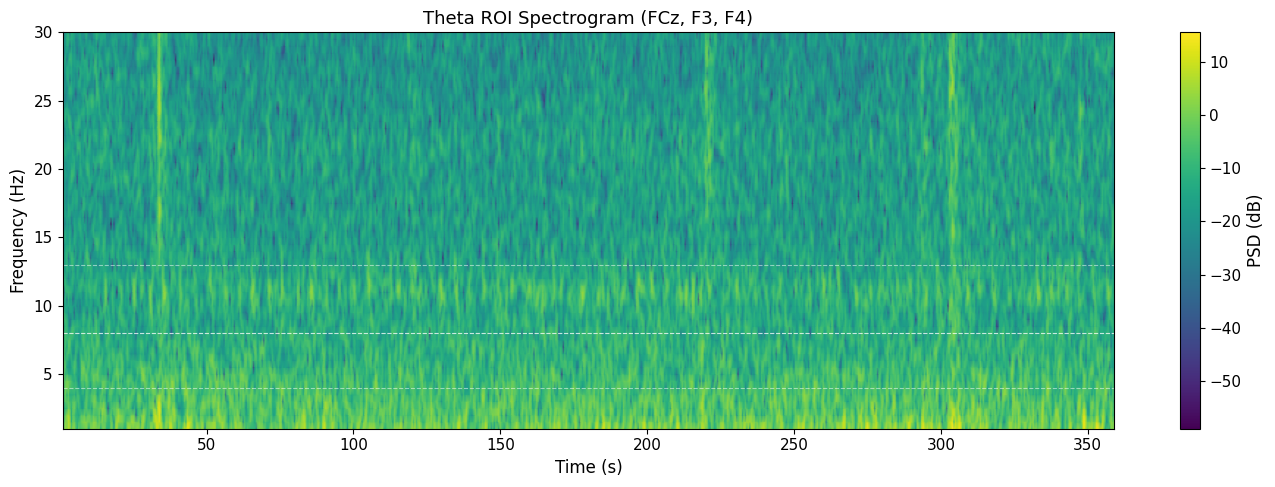

In [72]:
# Compute spectrogram for theta ROI (average of FCz, F3, F4)
roi_idx = [i for i, name in enumerate(ch_names) if name in THETA_ROI and i not in BAD_CHANNEL_IDX]
roi_signal = np.mean(eeg_clean[:, roi_idx], axis=1)

f_spec, t_spec, Sxx = signal.spectrogram(
    roi_signal, fs=SRATE, nperseg=2*SRATE, noverlap=int(1.5*SRATE),
    window='hann',
)

# Limit to 1–30 Hz
freq_lim = (f_spec >= 1) & (f_spec <= 30)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.pcolormesh(
    t_spec, f_spec[freq_lim], 
    10 * np.log10(np.maximum(Sxx[freq_lim], 1e-30)),
    shading='gouraud', cmap='viridis',
)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('Theta ROI Spectrogram (FCz, F3, F4)')
fig.colorbar(im, ax=ax, label='PSD (dB)')

# Mark band boundaries
for band_name, (lo, hi) in BANDS.items():
    if band_name in ('theta', 'alpha'):
        ax.axhline(lo, color='white', linestyle='--', alpha=0.5, linewidth=0.8)
        ax.axhline(hi, color='white', linestyle='--', alpha=0.5, linewidth=0.8)

fig.tight_layout()
plt.show()


## Step 11: Export Results & Next Steps

Save the individualized frequency estimates to a JSON file for use by the tACS protocol scripts.


In [75]:
import json
from datetime import datetime

# Build results dict
export = {
    'subject_id': EASY_FILE.stem.split('_')[1] if '_' in EASY_FILE.stem else 'unknown',
    'source_file': str(EASY_FILE),
    'created_at': datetime.now().isoformat(),
    'srate_hz': SRATE,
    'channels': ch_names,
    'bad_channels': [ch_names[i] for i in BAD_CHANNEL_IDX],
    'preprocessing': {
        'highpass_hz': HIGHPASS_HZ,
        'lowpass_hz': LOWPASS_HZ,
        'notch_hz': NOTCH_HZ,
        'reference': 'average',
    },
    'estimates': {},
}

for band_name, band_range in BANDS.items():
    classical = results.get(band_name, {})
    entry = {
        'band_range_hz': list(band_range),
        'classical_peak_hz': classical.get('peak_hz'),
        'classical_prominence_z': classical.get('prominence_z', 0),
        'classical_passes': classical.get('passes_criteria', False),
    }
    
    # Add specparam if available
    if SPECPARAM_AVAILABLE and specparam_results:
        roi_key = f"{band_name}_roi"
        if roi_key in specparam_results:
            sm = specparam_results[roi_key]
            ap = sm.results.params.aperiodic.params
            r_sq = sm.results.metrics.results['gof_rsquared']
            entry['specparam_r_squared'] = float(r_sq)
            entry['specparam_aperiodic'] = {
                'offset': float(ap[0]),
                'exponent': float(ap[1]),
            }
            pk_params = sm.results.params.periodic.params
            if pk_params.size > 0 and pk_params.ndim == 2:
                band_peaks = [
                    {'center_hz': float(p[0]), 'power': float(p[1]), 'bandwidth_hz': float(p[2])}
                    for p in pk_params
                    if band_range[0] <= p[0] <= band_range[1]
                ]
                entry['specparam_peaks'] = band_peaks
    
    export['estimates'][band_name] = entry

# Save
output_path = EASY_FILE.parent / f"{EASY_FILE.stem}_freq_estimates.json"
# Uncomment below to save:
# with open(output_path, 'w') as f:
#     json.dump(export, f, indent=2)
# print(f"Saved to: {output_path}")

# Print for review
print(json.dumps(export, indent=2, default=str))

{
  "subject_id": "sub-rebecca-pilot-2",
  "source_file": "/Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/nic/raw/20260602150340_sub-rebecca-pilot-2_Run 1.easy",
  "created_at": "2026-06-04T22:04:58.990131",
  "srate_hz": 500,
  "channels": [
    "F3",
    "Fp1",
    "FCz",
    "FT7",
    "F4",
    "P4",
    "P3"
  ],
  "bad_channels": [],
  "preprocessing": {
    "highpass_hz": 0.5,
    "lowpass_hz": 45.0,
    "notch_hz": 60.0,
    "reference": "average"
  },
  "estimates": {
    "theta": {
      "band_range_hz": [
        4.0,
        8.0
      ],
      "classical_peak_hz": 4.0,
      "classical_prominence_z": 0.0,
      "classical_passes": false,
      "specparam_r_squared": 0.9718091668712381,
      "specparam_aperiodic": {
        "offset": 0.6913260972837123,
        "exponent": 1.4181058380236529
      },
      "specparam_peaks": []
    },
    "alpha": {
      "band_range_hz": [
        8.0,
        13.0
      ],
      "classical_peak_hz": 11.0,
      "classical_promin

---

## Notes & Methodological Considerations

**1. Resting-state vs. task-locked theta estimation:**
The existing `theta_estimator.py` in the project is designed for *feedback-locked* theta — it epochs the EEG around behavioral feedback events and computes a time-frequency decomposition. That's the gold standard for the bandit task specifically. This notebook takes the complementary approach of *resting-state* spectral estimation, which is:
- Simpler (no behavioral events needed)
- Applicable before the task runs (useful for setting tACS frequency before the experiment)
- Used by multiple published tACS-theta studies (Reinhart & Nguyen, 2019; Fusco et al., 2021; the FM-theta mega-analysis)

**2. Why specparam matters:**
Raw PSD peaks in the 4–8 Hz range can be misleading. A steep aperiodic slope (common in frontal channels) creates a "pseudo-peak" where the 1/f falloff is steepest, which can masquerade as a theta peak. Specparam explicitly models and removes this component. If specparam finds *no* peak above the aperiodic background, that's an important negative finding — it means this participant may not have a clear individualized theta frequency, and the canonical 6 Hz fallback is appropriate.

**3. Electrode coverage limitations:**
With only 7 electrodes, we lack Fz (the canonical FM-theta site) and Cz. FCz is the best available proxy. We also can't do a full average reference or ICA with this few channels, so the preprocessing is intentionally minimal.

**4. Recording condition:**
This analysis assumes the EEG was recorded during resting state (ideally eyes-closed, ~3–5 minutes). If this is a task recording (e.g., during the bandit), the spectra will be dominated by task-evoked activity and the peak estimates may not reflect intrinsic oscillatory frequencies. In that case, consider using the feedback-locked approach from `theta_estimator.py` instead.

**5. Integration with the tACS protocol:**
The estimated theta frequency from this notebook can be passed to `select_theta_frequency.py` as a manual override, or saved as a theta estimate JSON that the existing pipeline will pick up automatically.
